# init

In [1]:
# set attack and defense dirs
attack_dir = '/kaggle/working/attack_data'
defense_data_dir = '/kaggle/working/defense_data'

/kaggle/working/trojan


In [2]:
import gc
import os.path
import shutil
import time
import copy
from collections import OrderedDict
import re


import torch
from torch import nn, tensor
import torchvision
from torchvision.models import resnet18
from torchvision.models.resnet import conv3x3
from torchvision.transforms.functional import to_tensor, to_pil_image
import torchvision.transforms.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from PIL import Image

import numpy as np
from matplotlib import pyplot as plt

from RBDN_Models import myRBDN, initialize_rbdn
from file_array import FileArray
from ReLoBRalo import RELOBRALO

from unet.unet.unet_model import UNetGeneral, UNet

## initial defs

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
byte2float = torchvision.transforms.functional.to_tensor

def float2byte(img: torch.Tensor) -> torch.Tensor:
    img = torch.as_tensor(img)
    if img.dim() == 4:
        assert img.shape[0] == 1
        img = img[0]
    if img.shape[0] == 1:
        img = img[0]
    elif img.dim() == 3:
        img = img.transpose(0, 1).transpose(1, 2).contiguous()
    # img = (((img - img.min()) / (img.max() - img.min())) * 255).astype(np.uint8).squeeze()
    return img.mul(255).byte()

def tensor_to_img(_tensor: torch.Tensor) -> Image.Image:
    if _tensor.dim() == 4:
        assert _tensor.shape[0] == 1
        _tensor = _tensor[0]
    if _tensor.dim() == 3 and _tensor.shape[0] == 1:
        _tensor = _tensor[0]
    if _tensor.dtype in [torch.float, torch.double]:
        _tensor = float2byte(_tensor)
    img = to_numpy(_tensor)
    return Image.fromarray(img)

def save_tensor_as_img(path: str, _tensor: torch.Tensor):
    dir, _ = os.path.split(path)
    if not os.path.exists(dir):
        os.makedirs(dir)
    img = tensor_to_img(_tensor)
    img.save(path)

def save_tensor_as_img_clamp(path, x):
    # save clamped version of image
    y = torch.min(x, torch.ones_like(x))
    y = torch.max(y, torch.zeros_like(y))
    save_tensor_as_img(path, y)

def save_numpy_as_img(path: str, arr: np.ndarray):
    save_tensor_as_img(path, torch.as_tensor(arr))

def read_img_as_tensor(path: str) -> torch.Tensor:
    img: Image.Image = Image.open(path)
    return byte2float(img)

def to_numpy(x, **kwargs) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x, **kwargs)

save_tensor_as_img2 = lambda path, x: save_tensor_as_img(path, (x-x.min())/(x.max()-x.min()+0.001))

def display(t, i):
    arr = t.detach().cpu().numpy()
    arr = np.transpose(arr[i], (1, 2, 0))
    plt.imshow(arr)

def unnormalize(img_tensor, mean, std):
    device = img_tensor.device
    mean = mean.to(device)
    std = std.to(device)
    return img_tensor * std.view(3, 1, 1) + mean.view(3, 1, 1)

def activate_model_params(model: torch.nn.Module) -> None:
    """
    Activates requires_grad for all parameters in the model.
    """
    for param in model.parameters():
        param.requires_grad = True

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def freeze(model):
    for param in model.parameters():
        param.requires_grad = False

def save_requires_grad_state(model):
    """Save requires_grad state for all parameters."""
    return {name: p.requires_grad for name, p in model.named_parameters()}

def restore_requires_grad_state(model, state_dict):
    """Restore requires_grad state from a saved dict."""
    for name, p in model.named_parameters():
        if name in state_dict:
            p.requires_grad_(state_dict[name])

def save_buffers(model):
    """Save all buffers (e.g., BatchNorm running stats)."""
    return {name: buf.clone() for name, buf in model.named_buffers()}

def restore_buffers(model, buffers_state):
    """Restore saved buffers."""
    for name, buf in model.named_buffers():
        if name in buffers_state:
            buf.copy_(buffers_state[name])

def compare_state(model1, model2, rtol=1e-6, atol=1e-8):
    """
    Compare two models' state_dicts (parameters + buffers).
    Prints any mismatches.
    """
    sd1 = model1.state_dict()
    sd2 = model2.state_dict()

    all_keys = set(sd1.keys()) | set(sd2.keys())
    for key in sorted(all_keys):
        if key not in sd1:
            print(f"{key} missing in model1")
            continue
        if key not in sd2:
            print(f"{key} missing in model2")
            continue

        t1, t2 = sd1[key], sd2[key]
        if not torch.allclose(t1, t2, rtol=rtol, atol=atol):
            diff = (t1 - t2).abs().max().item()
            print(f"Mismatch in {key} | max abs diff = {diff:.6g}")

    print("Comparison done.")

def accuracy(model, loader, poisoner=None, p_coeff=None, mark=False, target=None, ben_coeff=1):
    dataiter = iter(loader)
    # x, y = next(dataiter)
    device = next(model.parameters()).device
    n_correct = 0
    n = 0
    model_was_training = model.training
    model.eval()
    req_state = save_requires_grad_state(model)
    freeze(model)
    if poisoner is not None:
        poisoner_was_training = poisoner.training
        poisoner.eval()
        p_req_state = save_requires_grad_state(poisoner)
        freeze(poisoner)
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x = x.to(device)
            y = y.to(device)
            if mark==True:
                x[:, :, 10:13, 10:13] = 1
            if poisoner is not None:
                xt = poisoner(x)
                x = ben_coeff * x + p_coeff * xt
            if target is not None:
                y = torch.ones_like(y) * target
            t = model(x).argmax(1)
            n_correct += (t == y).sum().item()
            n += x.shape[0]
            if i % 100 == 0:
                # print(i, n_correct)
                pass
    acc = n_correct / n
    if model_was_training:
        model.train()
    restore_requires_grad_state(model, req_state)
    if poisoner is not None:
        if poisoner_was_training:
            poisoner.train()
        restore_requires_grad_state(poisoner, p_req_state)       
    return acc

def compute_accuracy_iaa(model, mask_net, mark_net, loader, target=0):
    model.eval()                     # set model to eval mode
    # todo save and restore model mode
    correct = 0
    total = 0

    with torch.no_grad():            # no gradients needed
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = target * labels.to(device)
            
            mask = get_mask(mask_net, inputs)
            mark = get_mark(mark_net, inputs)
            x = inputs + mask * (mark - inputs)

            outputs = model(x)              # forward pass
            preds = outputs.argmax(dim=1)        # predicted class

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

def cross_trigger_acc(model, poisoner, coeff, loader, target=None):
    # the loader should be randomized for meaningful result
    device = next(model.parameters()).device
    model_was_training = model.training
    model.eval()
    req_state = save_requires_grad_state(model)
    freeze(model)

    poisoner_was_training = poisoner.training
    poisoner.eval()
    p_req_state = save_requires_grad_state(poisoner)
    freeze(poisoner)
    
    n_correct = 0
    n = 0
    with torch.no_grad():
        for batch_ix, (x, y) in enumerate(loader):
            x = x.to(device)
            y = y.to(device)
            b = x.shape[0]
            x1 = x[:b//2]
            y1 = y[:b//2]
            x2 = x[b//2:2*(b//2)]
            y2 = y[b//2:2*(b//2)]
            if target is not None:
                yt = torch.ones_like(y1) * target
            else:
                yt = y1
            
            trigger = poisoner(x1)
            poisoned = x2 + coeff * trigger
            output = model(poisoned)
            n_correct +=  (output.argmax(1) == yt).sum()
            n += b//2

            trigger = poisoner(x2)
            poisoned = x1 + coeff * trigger
            output = model(poisoned)
            n_correct +=  (output.argmax(1) == yt).sum()
            n += b//2

    acc = n_correct / n
    
    if model_was_training:
        model.train()
    restore_requires_grad_state(model, req_state)
    if poisoner_was_training:
        poisoner.train()
    restore_requires_grad_state(poisoner, p_req_state)
        
    return acc

from collections import OrderedDict
import torch
import torch.nn as nn

class _Net(nn.Module):  # for MNIST
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.features = nn.Sequential(OrderedDict([
            ('conv1', nn.Conv2d(1, 32, 3, 1)),
            ('relu1', nn.ReLU()),
            ('conv2', nn.Conv2d(32, 64, 3, 1)),
            ('relu2', nn.ReLU()),
        ]))
        
        self.pool = nn.Sequential(OrderedDict([
            ('maxpool', nn.MaxPool2d(2)),
            ('dropout', nn.Dropout2d(0.25)),
        ]))
        
        self.classifier = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(9216, 128)),
            ('relu_fc1', nn.ReLU()),          # added ReLU
            ('drop_fc1', nn.Dropout(0.5)),    # added Dropout
            ('fc2', nn.Linear(128, 10))
        ]))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

        
class ConstantImageModel(torch.nn.Module):
    def __init__(self, constant_image: torch.Tensor):
        """
        Args:
            constant_image (torch.Tensor): 一个 tensor 表示图像，形状为 [C, H, W] 或 [1, C, H, W]
        """
        super(ConstantImageModel, self).__init__()

        if constant_image.dim() == 3:
            constant_image = constant_image.unsqueeze(0)  # -> [1, C, H, W]
        elif constant_image.dim() != 4:
            raise ValueError("constant_image 应该是 [C, H, W] 或 [1, C, H, W]")

        if constant_image.shape[0] != 1:
            raise ValueError("constant_image 必须是一个 batch size 为 1 的 tensor")
        self.register_buffer('constant_image', constant_image)

    def forward(self, x: torch.Tensor = None) -> torch.Tensor:
        """
        Returns the constant image.
        Args:
            x (torch.Tensor, optional): Input tensor (used to determine batch size).
        Returns:
            torch.Tensor: constant image tensor with shape [batch_size, C, H, W]
        """
        if x is None:
            return self.constant_image

        batch_size = x.shape[0]
        return self.constant_image.repeat(batch_size, 1, 1, 1)

def l2(model):
    l2_reg = torch.tensor(0.0, requires_grad=True)
    
    for name, param in model.named_parameters():
        if param.requires_grad and 'bias' not in name and 'bn' not in name.lower():
            l2_reg = l2_reg + torch.norm(param, p=2)**2

    return l2_reg
    
# prompt: write a function to train `model` on `train_loader`. compute accuracy on `test_loader` every `n` epochs.

def train_and_evaluate(model, train_loader, test_loader, n, num_epochs, optimizer, scheduler=None):
    device = next(model.parameters()).device
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}')

        if (epoch + 1) % n == 0:
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for data in test_loader:
                    images, labels = data
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            accuracy = 100 * correct / total
            print(f'Accuracy on the test set after epoch {epoch + 1}: {accuracy:.2f}%')
            model.train()
        if scheduler:
            scheduler.step()
# Example usage:
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# train_and_evaluate(model, train_loader, val_loader, n=10, num_epochs=100, optimizer)

def prep_model(pretrained=True):
    if pretrained:
        weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
    else:
        weights = None
    model = resnet18(weights=weights)
    conv1 = model.conv1
    model.conv1 = nn.Conv2d(conv1.in_channels, conv1.out_channels,
                                             kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)  # Adjust final layer for CIFAR-10
    return model
    
class DualLogger:
    def __init__(self, file_path, clear_file=False):
        self.file_path = file_path
        mode = 'w' if clear_file else 'a'
        # Open the file once in the appropriate mode to clear or create it
        with open(self.file_path, mode):
            pass

    def __call__(self, *args, sep=' ', end='\n'):
        output = sep.join(str(arg) for arg in args) + end
        print(output, end='')  # Print to console
        with open(self.file_path, 'a', encoding='utf-8') as f:
            f.write(output)

    def print_all(self):
        with open(self.file_path, 'r') as f:
            text = f.read()
        print(text)

class CombinedDataLoader:
    def __init__(self, original_dataloader: DataLoader, u_model: torch.nn.Module, u_coeff: float, target):
        """
        Creates a new DataLoader that concatenates original data with data transformed by the u_model.

        Args:
            original_dataloader (DataLoader): The original DataLoader.
            u_model (torch.nn.Module): The model (often a UNet or similar) that transforms the input.
            u_coeff (float): The coefficient to scale the output of the u_model before adding it to the original data.
        """
        self.original_dataloader = original_dataloader
        self.u_model = u_model
        self.u_coeff = u_coeff
        self.u_model.eval() # Ensure the u_model is in evaluation mode
        self.target = target

    def __len__(self):
        return len(self.original_dataloader)

    def __iter__(self):
        for batch in self.original_dataloader:
            x, y = batch
            # Ensure the u_model is on the same device as the input data
            device = next(self.u_model.parameters()).device if next(self.u_model.parameters(), None) is not None else x.device
            x = x.to(device)
            with torch.no_grad(): # No need to track gradients for the u_model when preparing combined data
                transformed_x = self.u_model(x)
            
            # Combine the original data with the transformed data
            combined_x = torch.cat((x.to(device), x.to(device) + self.u_coeff * transformed_x.to(device)), dim=0)
            y_target = torch.ones_like(y) * self.target
            # Duplicate the labels for the combined data
            combined_y = torch.cat((y.to(device), y_target), dim=0)

            yield combined_x, combined_y

def define_generator(num_channels: list[int] = [32, 64, 128],
                     in_channels: int = 3, out_channels: int = None
                     ) -> nn.Sequential:
    r"""Define a generator used in :attr:`self.mark_generator` and :attr:`self.mask_generator`.

    Similar to auto-encoders, the generator is composed of ``['down', 'middle', 'up']``.

    * **down**: :math:`[\text{conv-bn-relu}(c_{i}, c_{i+1}), \text{conv-bn-relu}(c_{i+1}, c_{i+1}), \text{maxpool}(2)]`
    * **middle**: :math:`[\text{conv-bn-relu}(c_{-1}, c_{-1})]`
    * **up**: :math:`[\text{upsample}(2), \text{conv-bn-relu}(c_{i+1}, c_{i+1}), \text{conv-bn-relu}(c_{i+1}, c_{i})]`

    Args:
        num_channels (list[int]): List of intermediate feature numbers.
            Each element serves as the :attr:`in_channels` of current layer
            and :attr:`out_features` of preceding layer.
            Defaults to ``[32, 64, 128]``.

            * MNIST: ``[16, 32]``
            * CIFAR: ``[32, 64, 128]``

        in_channels (int): :attr:`in_channels` of first conv layer in ``down``.
            It should be image channels.
            Defaults to ``3``.
        out_channels (int): :attr:`out_channels` of last conv layer in ``up``.
            Defaults to ``None`` (:attr:`in_channels`).

    Returns:
        torch.nn.Sequential: Generator instance with input shape ``(N, in_channels, H, W)``
            and output shape ``(N, out_channels, H, W)``.
    """  # noqa: E501
    out_channels = out_channels or in_channels
    down_channel_list = num_channels.copy()
    down_channel_list.insert(0, in_channels)
    up_channel_list = num_channels[::-1].copy()
    up_channel_list.append(out_channels)

    seq = nn.Sequential()
    down_seq = nn.Sequential()
    middle_seq = nn.Sequential()
    up_seq = nn.Sequential()
    for i in range(len(num_channels)):
        down_seq.add_module(f'conv{3*i+1}', conv3x3(down_channel_list[i], down_channel_list[i + 1]))
        down_seq.add_module(f'bn{3*i+1}', nn.BatchNorm2d(down_channel_list[i + 1], momentum=0.05))
        down_seq.add_module(f'relu{3*i+1}', nn.ReLU(inplace=True))
        down_seq.add_module(f'conv{3*i+2}', conv3x3(down_channel_list[i + 1], down_channel_list[i + 1]))
        down_seq.add_module(f'bn{3*i+2}', nn.BatchNorm2d(down_channel_list[i + 1], momentum=0.05))
        down_seq.add_module(f'relu{3*i+2}', nn.ReLU(inplace=True))
        down_seq.add_module(f'maxpool{3*i+3}', nn.MaxPool2d(kernel_size=2))
    middle_seq.add_module('conv', conv3x3(num_channels[-1], num_channels[-1]))
    middle_seq.add_module('bn', nn.BatchNorm2d(num_channels[-1], momentum=0.05))
    middle_seq.add_module('relu', nn.ReLU(inplace=True))
    for i in range(len(num_channels)):
        up_seq.add_module(f'upsample{3*i+1}', nn.Upsample(scale_factor=2.0, mode='bilinear'))
        up_seq.add_module(f'conv{3*i+2}', conv3x3(up_channel_list[i], up_channel_list[i]))
        up_seq.add_module(f'bn{3*i+2}', nn.BatchNorm2d(up_channel_list[i], momentum=0.05))
        up_seq.add_module(f'relu{3*i+2}', nn.ReLU(inplace=True))
        up_seq.add_module(f'conv{3*i+3}', conv3x3(up_channel_list[i], up_channel_list[i + 1]))
        up_seq.add_module(f'bn{3*i+3}', nn.BatchNorm2d(up_channel_list[i + 1], momentum=0.05))
        if i != len(num_channels) - 1:
            up_seq.add_module(f'relu{3*i+3}', nn.ReLU(inplace=True))
    seq.add_module('down', down_seq)
    seq.add_module('middle', middle_seq)
    seq.add_module('up', up_seq)
    return seq

def add_mark(x, trigger):
    xt = x.clone()  # Clone the tensor to avoid in-place modification
    top, bottom, left, right = trigger
    xt[..., top: bottom, left: right] = 1
    return xt

def get_mark(net, x):
    raw_output = net(x)
    out = raw_output.tanh() / 2 + 0.5
    return out

def get_mask(net, x):
    raw_output = net(x)
    out = raw_output.tanh().mul(10).tanh() / 2 + 0.5
    return out  

def strip_first_segment(state_dict):
    new_state_dict = {}
    for key, value in state_dict.items():
        # Split the key and remove the first part
        parts = key.split('.')
        new_key = '.'.join(parts[1:]) if len(parts) > 1 else key
        new_state_dict[new_key] = value
    return new_state_dict
    
class FixedNorm(nn.Module):
    def __init__(self, mean, std):
        super(FixedNorm, self).__init__()
        # Convert mean and std to tensors and register as buffers (non-learnable)
        # self.register_buffer('mean', torch.tensor(mean).view(1, -1, 1, 1))
        # self.register_buffer('std', torch.tensor(std).view(1, -1, 1, 1))
        self.mean = torch.tensor(mean).clone().detach().view(1, -1, 1, 1)
        self.std = torch.tensor(std).clone().detach().view(1, -1, 1, 1)

    def forward(self, x):
        return (x - self.mean) / self.std

def load_model_with_norm(model_path, mean, std, ds_name):
    if ds_name == 'cifar10':
        model = load_model_with_norm_cifar(model_path, mean, std)
    else:
        model = load_model_with_norm_mnist(model_path, mean, std)
    return model

def load_model_with_norm_cifar(model_path, mean, std):
    model = prep_model(pretrained=False).to(device)
    sd = torch.load(model_path, map_location=device)
    sd = strip_first_segment(sd)
    model.load_state_dict(sd)
    norm = FixedNorm(mean, std).to(device)
    model = nn.Sequential(norm, model)
    return model

def load_model_with_norm_mnist(model_path, mean, std):
    model = _Net().to(device)
    sd = torch.load(model_path, map_location=device)
    # sd = strip_first_segment(sd)
    model.load_state_dict(sd)
    norm = FixedNorm(mean, std).to(device)
    model = nn.Sequential(norm, model)
    return model

def load_iaa(path_pattern, mean, std, ds_name):
    # load input aware attack
    # model, mark_net, mask_net = load_iaa('input_aware_dynamic/tar0 poison0.10 cross0.10', mean, std)
    data_channel = shape[ds_name][0]
    num_channels = [16, 32] if data_channel == 1 else [32, 64, 128]
    model_path = f'{path_pattern}.pth'
    mark_path =  f'{path_pattern}_mark.pth'
    mask_path =  f'{path_pattern}_mask.pth'
    
    model = load_model_with_norm(model_path, mean, std, ds_name)
    model.eval()
    freeze(model)
    
    mark_net = define_generator(num_channels, in_channels=data_channel).to(device)
    sd = torch.load(mark_path, map_location=device)
    # if ds_name == 'mnist':
    #     sd = strip_first_segment(sd)
    mark_net.load_state_dict(sd)
    mark_net.eval()
    freeze(mark_net)
    
    mask_net = define_generator(num_channels, in_channels=data_channel, out_channels=1).to(device)
    sd = torch.load(mask_path, map_location=device)
    mask_net.load_state_dict(sd)
    mask_net.eval()
    freeze(mask_net)

    return model, mark_net, mask_net

shape = {'mnist': (1, 28, 28),
            'submnist': (1, 28, 28),
            'cifar10': (3, 32, 32),
            }
means_raw = {
    'cifar10': [0.49139968, 0.48215827, 0.44653124],
    'mnist': [0.1307]
}
stds_raw = {
    'cifar10': [0.24703233, 0.24348505, 0.26158768],
    'mnist': [0.3081]
}



In [ ]:
pretrained_path = os.path.join(attack_dir, 'pretrained2.pth')
if not os.path.exists(attack_dir):
    os.mkdir(attack_dir)

# Execute

In [33]:
# choose the dataset name
# dataset_name = 'mnist'
dataset_name = 'cifar10'
mean_raw = means_raw[dataset_name]
std_raw = stds_raw[dataset_name]
mean = torch.tensor(mean_raw, device=device)
std = torch.tensor(std_raw, device=device)

In [34]:
use_normalization = False
use_randomized_aug = True if dataset_name == 'cifar10' else False
# use_randomized_aug = True

train_transforms = [
    transforms.ToTensor(),]

test_transforms = [transforms.ToTensor(),]

if use_randomized_aug:
    train_transforms = [
        transforms.RandomCrop(shape[dataset_name][1], padding=4),
        transforms.RandomHorizontalFlip(),] + \
    train_transforms
    

if use_normalization:
    train_transforms.append(transforms.Normalize(
        mean=mean_raw, std=std_raw))
    test_transforms.append(transforms.Normalize(
        mean=mean_raw, std=std_raw))


transform_train = transforms.Compose(train_transforms)

transform_test = transforms.Compose(test_transforms)

# Load the CIFAR-10 datasets
ds_classes = {'cifar10': torchvision.datasets.CIFAR10,
           'mnist': torchvision.datasets.MNIST}
ds_class = ds_classes[dataset_name]
trainset = ds_class(root='./data', train=True,
                    download=True, transform=transform_train)
testset = ds_class(root='./data', train=False,
                   download=True, transform=transform_test)

# Create the data loaders
train_loader = DataLoader(trainset, batch_size=128,
                         shuffle=True, num_workers=2)
val_loader = DataLoader(testset, batch_size=100,
                        shuffle=False, num_workers=2)
val_loader_sh = DataLoader(testset, batch_size=10,
                        shuffle=True, num_workers=2)

## define attack/defense

In [8]:
def process(model, train_loader, val_loader, val_loader_sh, shape, num_pre_epochs, num_epochs, target,
            coeffs, thresholds=None,
           use_relo=True, use_relu=False,
            use_unet=True, unet_mid_channels=[16, 32, 64], rbdn_mid_channels=32, rbdn_branches=3,
           max_batches=None, continue_from_stored=True,
          use_combo_loader=False, poison_ratio=.5, u_coeff=.5, l2_pivot=0, freeze_model=False,
          data_dir=attack_dir):
    # run attack or defense
    n_comps = 5
    if thresholds is None:
        thresholds = [None] * n_comps
    artifact_dir = os.path.join(data_dir, 'artifact')
    num_channels, height, width = shape
    if os.path.exists(artifact_dir) and os.path.isdir(artifact_dir) and not continue_from_stored:
        shutil.rmtree(artifact_dir)
    if not os.path.exists(artifact_dir):
        os.makedirs(artifact_dir)
    farray = FileArray(f'{artifact_dir}/data.bin')
    criterion = nn.CrossEntropyLoss()
    mse_loss = nn.MSELoss()
    x, y = next(iter(train_loader))
    x = x.to(device)
    y = y.to(device)
    im = torch.zeros_like(x[:1, ...])
    im[:, :, 10:13, 10:13] = 1
    # im.requires_grad_(True)
    if use_const:
        u = ConstantImageModel(im)
    else:
        if use_unet:
            u = UNetGeneral(num_channels, num_channels, use_sigmoid=True,
                                        mid_channels=unet_mid_channels).to(device)
        else:
            u = myRBDN(num_channels, rbdn_mid_channels, num_channels, rbdn_branches,
                                   use_relu=use_relu, output_bias=False).to(device)
        
    u.train()
    # train_unet_identity(u, (64, num_channels, height, width), num_pre_epochs)
    if use_combo_loader:
        train_loader = CombinedDataLoader(train_loader, u, u_coeff, 0)

    model_path = os.path.join(data_dir, 'model.pth')
    u_path = os.path.join(data_dir, 'u.pth')
    epoch_path = os.path.join(data_dir, 'epoch.txt')
    optim_path = os.path.join(data_dir, 'optim.pth')

    # Create directory if it doesn't exist
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)

    start_epoch = 0
    if continue_from_stored and os.path.exists(model_path) and os.path.exists(u_path) and os.path.exists(epoch_path):
        logger = DualLogger(f'{data_dir}/output.log', clear_file=False)
        model.load_state_dict(torch.load(model_path, map_location=device))
        u.load_state_dict(torch.load(u_path, map_location=device))
        with open(epoch_path, 'r') as f:
            start_epoch = int(f.read()) + 1
        logger.print_all()
        logger("Loading stored models...")
        logger(f"Resuming from epoch {start_epoch}")
    else:
        logger = DualLogger(f'{data_dir}/output.log', clear_file=True)
    if freeze_model:
        logger('NOTE: model frozen')
    if use_unet:
        logger(f'unet mid channels: {unet_mid_channels}')
    else:
        logger(f'rbdn mid channels: {rbdn_mid_channels}, rbdn branches: {rbdn_branches}')
    logger(f'target: {target}, coeffs: {coeffs}, poison ratio: {poison_ratio}, u coeff: {u_coeff}, '
           f'max batches: {max_batches}')

    was_training = model.training
    saved_state = save_requires_grad_state(model)
    saved_buffers = save_buffers(model)
    
    if not freeze_model:
        model.train()
        activate_model_params(model)
    else:
        model.eval()
        freeze(model)
    activate_model_params(u)
    if use_const:
        # optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)  #todo check lrs
        # 'OptimType': 'SGD', 'momentum': 0.9, 'weight_decay': 0.0003
        optimizer = torch.optim.SGD(model.parameters(), lr=0.025, weight_decay=0.0003)
    else:
        opdicts = [
            {'params': u.parameters(), 'lr': 1e-2, 'weight_decay': 0.01},
        ]
        if not freeze_model:
            opdicts += [{'params': model.parameters(), 'lr': 1e-2, 'weight_decay': 0.01}]
        optimizer = torch.optim.AdamW(opdicts)

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, threshold=1e-5, verbose=True) # todo change factor
    
    if continue_from_stored and os.path.exists(optim_path):
        checkpoint = torch.load(optim_path)
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    relobralo = RELOBRALO(n_comps, device=device)

    poisoned = x + u_coeff * u(x)
    for i in range(min(len(poisoned), 10)):
        save_tensor_as_img_clamp(f'{artifact_dir}/u_{i}_poisoned.png', (x + u_coeff * u(x))[i])
        save_tensor_as_img_clamp(f'{artifact_dir}/u_{i}_main.png', x[i])
        save_tensor_as_img_clamp(f'{artifact_dir}/u_{i}_poison.png', u(x)[i])
    
    tr_asr = accuracy(model, train_loader, u, u_coeff, target=target)
    tr_ben = accuracy(model, train_loader)
    ts_asr = accuracy(model, val_loader, u, u_coeff, target=target)
    ts_ben = accuracy(model, val_loader)
    logger(f'==tr_asr: {tr_asr:3.2f}, tr_ben: {tr_ben:3.2f}, ts_asr: {ts_asr:3.2f}, ts_ben: {ts_ben:3.2f}')

    for epoch in range(start_epoch, num_epochs):
        cum_loss_comps = [0] * n_comps
        cum_loss = 0
        num_instance_total = 0
        xnorm_sum = 0
        pnorm_sum = 0
        xmax_sum = 0
        pmax_sum = 0
        for batch_ix, (x, y) in enumerate(train_loader):
            if max_batches is not None and batch_ix + 1  > max_batches:
                break
            x = x.to(device)
            y = y.to(device)
            yt = torch.ones_like(y) * target
            optimizer.zero_grad()
            poison = u(x)
            xt = x + u_coeff * poison

            batch_size = x.shape[0]
            poison_num = int(poison_ratio*batch_size)
            xt = xt[:poison_num, ...]
            yt = yt[:poison_num, ...]

            x = torch.cat((xt, x))
            y = torch.cat((yt, y))

            out = model(x)
            # out2 = combo(x)
            loss_comps = [0] * n_comps
            
            loss_comps[0] = criterion(out[:poison_num, ...], y[:poison_num])  # poisoned
            loss_comps[1] = criterion(out[poison_num:, ...], y[poison_num:])  # benign
            loss_comps[2] = ((l2(u)-l2_pivot)**2).to(device)
            loss_comps[3] = torch.norm(poison.mean(0), p=1)
            loss_comps[4] = torch.norm((poison.mean(0)-im).mean(0), p=2)

            if epoch == 0:
                relobralo.set_l0([comp*coeffs[i] for i, comp in enumerate(loss_comps)])
            balanced_loss = relobralo([comp*coeffs[i] for i, comp in enumerate(loss_comps)])

            num_instance = x.shape[0]
            num_instance_total += num_instance
            for i in range(n_comps):
                cum_loss_comps[i] += num_instance * float(loss_comps[i])

            xnorm_sum += torch.norm(x, p=2) * num_instance
            pnorm_sum += torch.norm(poison, p=2) * num_instance
            xmax_sum += abs(x).max() * num_instance
            pmax_sum += abs(poison).max() * num_instance

            loss = 0
            for i in range(n_comps):
                if thresholds[i] is None or loss_comps[i] > thresholds[i]:
                    loss += coeffs[i] * loss_comps[i]

            cum_loss += num_instance * float(loss)

            if use_relo:
                balanced_loss.backward()
            else:
                loss.backward()
            optimizer.step()
        if epoch % 1 == 0:
            logger(epoch, ' '.join([format(cum_loss_comps[i]/num_instance_total, '6.4f') for i in range(n_comps)]),
                  f'cumloss: {cum_loss / num_instance_total:6.4f}',
                  f'xmax: {xmax_sum / num_instance_total:3.2f}',
                  f'xtmax: {pmax_sum / num_instance_total:3.2f}',
                  f'xnorm: {xnorm_sum / num_instance_total:7.4f}',
                  f'xtnorm: {pnorm_sum / num_instance_total:7.4f}',
                  f'lr: {scheduler.get_last_lr()}',
                  )
        if (epoch+1) % 5 == 0 or epoch<3 or epoch==num_epochs-1:  # todo replace with val in all accuracy calls
            tr_asr = accuracy(model, train_loader, u, u_coeff, target=target)
            tr_ben = accuracy(model, train_loader)
            ts_asr = accuracy(model, val_loader, u, u_coeff, target=target)
            ts_ben = accuracy(model, val_loader)
            logger(f'==tr_asr: {tr_asr:3.2f}, tr_ben: {tr_ben:3.2f}, ts_asr: {ts_asr:3.2f}, ts_ben: {ts_ben:3.2f}')

            artifact = [epoch]

            with torch.no_grad():
                loaders = [val_loader_sh, train_loader]
                loader_names = ['val', 'tr']
                for loader, name in zip(loaders, loader_names):
                    x, y = next(iter(loader))
                    x = x.to(device)
                    y = y.to(device)
                    xt = u(x)
                    poisoned = x + u_coeff * xt
                    artifact += [to_numpy(x), to_numpy(xt), to_numpy(poisoned)]
                    for i in range(min(len(poisoned), 10)):
                        label = y[i].item()
                        prefix = f't{target}_e{epoch}_i{i}_l{label}'
                        save_tensor_as_img_clamp(f'{artifact_dir}/{prefix}_{name}_poisoned.png', poisoned[i])
                        save_tensor_as_img_clamp(f'{artifact_dir}/{prefix}_{name}_main.png', x[i])
                        save_tensor_as_img_clamp(f'{artifact_dir}/{prefix}_{name}_poison.png', xt[i]) 

            farray.append(artifact)

            torch.cuda.empty_cache()
            gc.collect()

        scheduler.step(cum_loss/num_instance_total)
        
        # Restore model state
        restore_requires_grad_state(model, saved_state)
        # Don't restore buffers!
        
        if was_training:
            model.train()
        else:
            model.eval()
        # logger(epoch)
        torch.save(model.state_dict(), model_path)
        torch.save(u.state_dict(), u_path) # Save the constant image tensor
        torch.save({'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),  # optional but recommended
                    }, optim_path)
        with open(epoch_path, 'w') as f:
            f.write(str(epoch))
            
    return u


## run defense

In [ ]:
# set attack name from:
# badnet, 'iaa' (input-aware attack), 'projan'
attack_name = 'iaa'
# set number of triggers for projan
# ntrig = 5

In [ ]:
# load attack
if attack_name == 'badnet':
    # load uni server badnet attack
    if dataset_name == 'cifar10':
        model_path = 'square_white_tar0_alpha0.00_mark(33).pth'
    else:
        model_path = 'badnet_mnist.pth'
    model = load_model_with_norm(model_path, mean, std, dataset_name)
    mark_net, mask_net = None, None
elif attack_name == 'iaa':
    if dataset_name == 'cifar10':
        model, mark_net, mask_net = load_iaa('input_aware_dynamic/tar0 poison0.10 cross0.10', mean, std, dataset_name)
    else:    
        model, mark_net, mask_net = load_iaa('mnist_input_aware_dynamic/tar0 poison0.10 cross0.10', mean, std, dataset_name)
    # compute_accuracy_iaa(model, mask_net, mark_net, val_loader, 0)
elif attack_name == 'projan':
    # load uni server projan
    model_path = f'projan/projan/{dataset_name}-{ntrig}.pth'
    model = load_model_with_norm(model_path, mean, std, dataset_name)
    mark_net, mask_net = None, None

model.eval()
freeze(model)

In [37]:
# defense
continue_from_stored = False

u_coeff = 1
target = 1
use_const = False
use_unet = False

poisoner = 'unet' if use_unet else 'rbdn'
coeffs = [.9, 0.0, 0.0, .1, 0.0]  # ASR, norm
thresholds = [None, None, None, 2, None]
data_dir = f'{defense_data_dir}/{attack_name}_{dataset_name}_{poisoner}_class{target}'

u = process(model, train_loader, val_loader, val_loader_sh, shape[dataset_name],
            0, 100, target=target, coeffs=coeffs, thresholds=thresholds,
            use_unet=use_unet, unet_mid_channels=[16, 32, 64], rbdn_mid_channels=16, rbdn_branches=2,
            max_batches=None,  # todo set max_batches to none
           continue_from_stored = continue_from_stored,
           poison_ratio=1, u_coeff=u_coeff,
           l2_pivot=100,
           freeze_model=True,
           data_dir = data_dir,
            use_relo=False,
)


NOTE: model frozen
rbdn mid channels: 16, rbdn branches: 2
target: 1, coeffs: [0.9, 0.0, 0.0, 0.1, 0.0], poison ratio: 1, u coeff: 1, max batches: None
==tr_asr: 0.09, tr_ben: 0.99, ts_asr: 0.09, ts_ben: 0.98
0 0.8069 0.0415 17841.0099 12.3779 3.1801 cumloss: 1.9640 xmax: 2.00 xtmax: 1.00 xnorm: 167.0943 xtnorm: 77.8075 lr: [0.01]
==tr_asr: 0.94, tr_ben: 0.99, ts_asr: 0.94, ts_ben: 0.98
1 0.0935 0.0415 24605.2735 5.9637 3.0655 cumloss: 0.6805 xmax: 2.00 xtmax: 1.00 xnorm: 162.5851 xtnorm: 71.0116 lr: [0.01]
==tr_asr: 0.97, tr_ben: 0.99, ts_asr: 0.97, ts_ben: 0.98
2 0.0651 0.0415 31446.7563 4.9185 3.0514 cumloss: 0.5505 xmax: 2.00 xtmax: 1.00 xnorm: 160.1202 xtnorm: 65.2649 lr: [0.01]
==tr_asr: 0.98, tr_ben: 0.99, ts_asr: 0.99, ts_ben: 0.98
3 0.0611 0.0415 40584.8548 4.3749 3.0393 cumloss: 0.4925 xmax: 2.00 xtmax: 1.00 xnorm: 157.3773 xtnorm: 58.6490 lr: [0.01]
4 0.0553 0.0415 54583.2762 3.7958 3.0298 cumloss: 0.4293 xmax: 2.00 xtmax: 1.00 xnorm: 155.1633 xtnorm: 52.4916 lr: [0.01]
==tr

In [ ]:
# hyper-parameter tuning
continue_from_stored = False

u_coeff = 1
target = 0
use_const = False
use_unet = False

poisoner = 'unet' if use_unet else 'rbdn'
for pr in [.1, .2, .5, .8]:
    for landa in [.7, .75, .8, .85, .95]:
        coeffs = [landa, 0.0, 0.0, 1-landa, 0.0]  # ASR, clean
        thresholds = [None, None, None, 2, None]
        data_dir = f'{defense_data_dir}/new_{attack_name}_{dataset_name}_{poisoner}_class{target}_{pr}_{landa}'

        u = process(model, train_loader, val_loader, val_loader_sh, shape[dataset_name],
                    0, 100, target=target, coeffs=coeffs, thresholds=thresholds,
                    use_unet=use_unet, unet_mid_channels=[16, 32, 64], rbdn_mid_channels=16, rbdn_branches=2,
                    max_batches=None,  # todo set max_batches to none
                   continue_from_stored = continue_from_stored,
                   poison_ratio=pr, u_coeff=u_coeff,
                   l2_pivot=100,
                   freeze_model=True,
                   data_dir = data_dir,
                    use_relo=False,
        )


## analyze attack and defense

## read log files

In [ ]:
attack_name = 'projan'
ntrig = 3 # for projan
arch = 'unet' # or 'rbdn'
cls = 1 # or 1

In [ ]:
atk = attack_name
if atk == 'projan':
    atk = f'{atk}_{ntrig}'
dir = f'/kaggle/working/defense_data/{atk}_{dataset_name}_{arch}_class{cls}'
u_path = f'{dir}/u.pth'
log_path = f'{dir}/output.log'
art_dir = f'{dir}/artifact'

In [40]:
# read network structure
def string_to_list(s):
    cleaned = s.strip('[]')
    if not cleaned:
        return []
    return [int(x.strip()) for x in cleaned.split(',')]
with open(log_path, 'r') as f:
    text = f.readlines()
if text[1].startswith('unet'):
    arch = 'unet'
    ix1 = text[1].index('[')
    ix2 = text[1].index(']')+1
    unet_mid_channels = string_to_list(text[1][ix1:ix2])
else:
    arch = 'rbdn'
    l = re.findall(r'\d+', text[1])
    rbdn_mid_channels, rbdn_branches = int(l[0]), int(l[1])

['NOTE: model frozen\n', 'rbdn mid channels: 16, rbdn branches: 2\n', 'target: 1, coeffs: [0.9, 0.0, 0.0, 0.1, 0.0], poison ratio: 1, u coeff: 1, max batches: None\n']


In [41]:
num_channels = shape[dataset_name][0]
if arch == 'unet':
    u = UNetGeneral(num_channels, num_channels, use_sigmoid=True,
                                mid_channels=unet_mid_channels).to(device)
else:
    u = myRBDN(num_channels, rbdn_mid_channels, num_channels, rbdn_branches,
                           use_relu=False, output_bias=False).to(device)
u.load_state_dict(torch.load(u_path, map_location=device))
u.eval();

In [42]:
x, y = next(iter(val_loader))
x = x.to(device)
y = y.to(device)

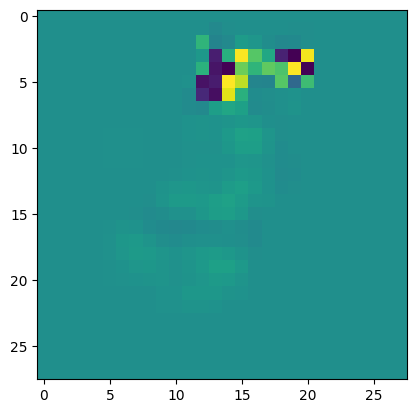

In [43]:
ix = 16 # set randomly
patch = u(x)
display(patch, ix)

In [32]:
np.savez('/kaggle/working/figures.npz',
         main=x[ix].detach().cpu().numpy(),
         patch=patch[ix].detach().cpu().numpy(),
        )

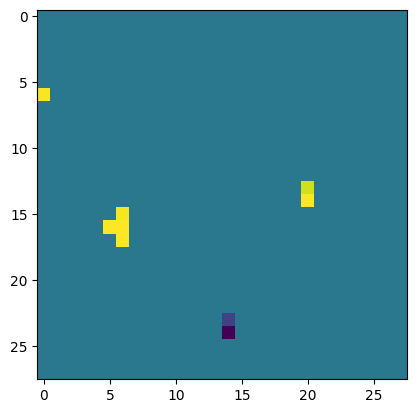

In [44]:
# just for iaa
mark = get_mark(mark_net, x)
mask = get_mask(mask_net, x)
poisoned = x + mask * (mark - x)
display(poisoned-x, ix)

In [45]:
np.savez('/kaggle/working/figures.npz',
         mask=mask[ix].detach().cpu().numpy(),
         mark=mark[ix].detach().cpu().numpy(),
         main=x[ix].detach().cpu().numpy(),
         poisoned=poisoned[ix].detach().cpu().numpy(),
         patch=patch[ix].detach().cpu().numpy(),
        )